<font color=#009afa size=50>DAT5004-Big Data Management Systems</font>

<font size=50 color=#00c382>Task One - Web Scraping Task</font><br>
<font size=35>Extracting Movie Information from FilmCrave.com</font>

**Assessment Code:** PRAC1 (Task 1)

**Author:** Tom Rowan, ST20285213

**Course:** DAT5004_S2_24

**Course Tutor:** Dr. Sandeep Singh Sengar

<p>

<img src=https://datascience.daemonchild.com/year2/dat5004/prac1/images/filmcrave-logo.png />

> FilmCrave (https://www.filmcrave.com/list_top_movie.php) is a website where people share their favourite
movies, reviews, and ratings. It has a huge collection of films, complete with rankings, genres, and other details.

> The goal of this project is to gather information on over 1,000 movies from this site. The data we want includes the
Year of Release, Overall Rating, Language, Genre, MPAA Rating (like PG or R), Director, Actors, and a short Plot
summary.

> To do this, you’ll use Python. A tool called BeautifulSoup will help you read and understand the webpage's layout
to pull out the data we need. Another tool, Requests, will help you connect to the website and fetch its content.
Once you have the data, you’ll use Pandas to organise it neatly into a table format, and then save it as a CSV file.
After gathering the data, you’ll clean it up, fix any missing or incorrect values, and make sure everything is
consistent. Then, you’ll analyse it. you’ll create visual charts, like bar graphs showing popular genres or line graphs
tracking how movie ratings have changed over time, using tools like Matplotlib and Seaborn. This project will
teach valuable skills in web scraping, data organisation, and analysis.

## Install and Import Required Libraries

In [2]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# BeautifulSoup and Requests
from bs4 import BeautifulSoup
import requests

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.pyplot import figure
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Tabulate
from tabulate import tabulate

# Pillow
from PIL import Image

# Wordcloud
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# Unidecode
from unidecode import unidecode
import chardet

# Random
import random

# OS
import os

# Colorama
from colorama import Fore, Back, Style

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Site Friendly Behaviour

Scraping a large amount of data from a website like FilmCrave.com may be seen as unfriendly behaviour by the site admins. Continually scraping large amounts of data from the site could result in a source IP address being banned. 

 

There are several reasons for this. One is because there is a financial implication each time the website retrieves data from the database, generates a page and delivers the data to a browser. CPU processing time and bandwidth must be paid for, particularly if the website is hosted within a cloud provider such as Microsoft Azure, Amazon AWS or Google Compute Platform. Furthermore, the data belongs to the site and there may be a perception that scraping this data is equivalent to theft. 


The code in this notebook below allows the user to scrape either the Top 1000 movies or to scrape the entire database of movie data. To minimise the impact against the website, I have run the full data scraping exercise to collect all the movies data only a single time and saved the data into a CSV file to accompany this Jupyter notebook. 


When following variables are set to False, only a minimal scraping exercise will be run as a proof of concept. In thios case, the data from the CSV file will be loaded for the analysis phase.  


If the _FULL_WEB_SCRAPE_ variable is set to True, the full exercise will be run, which will take up to eight hours to complete. This generates a lot of traffic against the website.


If the _TOP1000_WEB_SCRAPE_ variable is set to True, then 1000 movies will be gathered. This also takes a while. 


To minimise the possibility of detection, the code below utilises a web proxy to effectively hide the IP address of the python client for each GET request.


NB: The notebook has been saved with the output intact to save the user from running the code and waiting for the results.

In [4]:
_FULL_WEB_SCRAPE_ = False
_TOP1000_WEB_SCRAPE_ = False

<font size=30 color=#00c382>Define Functions</font><br>

## Fetch Page Content Safely

The fetch_page function collects the HTML content for a page. It checks that the page has been returned correctly. 

The FilmCrave website responds with a 404 code when there is no movie data at a given URL. 

The web request is wrapped within a Try/Except/Finally block to catch any web site related errors or connectivity issues. 

In [5]:
def fetch_page (url, http_proxy = None):

    # Wrap the HTTP GET request in a try/except/finally block
    try:
        # Use the proxy as provided
        proxies = {'http': http_proxy}

        # Fetch the page
        response = requests.get(url, proxies = proxies)

        # Check if the GET request was successful (status code 200)
        if response.status_code == 200:
            html_text = str(response.text)
        else:
            # 404 is a legitimate response for the movies website
            html_text = str(response.status_code)

    except Exception as e:
        print (Fore.RED + f"[Error] Failed to fetch {url}")
        print (f"[Error] {e}" + Fore.RESET)
        html_text= ""

    finally:
        return html_text

## Web Proxies

To mask the multiple GET requests that I made against the FilmCrave website, I used a list of free open web proxies.
These are available from this GitHub repository: [https://github.com/proxifly/free-proxy-list](https://github.com/proxifly/free-proxy-list).

This list includes HTTP and socks4 proxies. The latter are not suitable for passing to the requests library, so this function removes these, returning a list of http proxies only. The function defaults to the GB proxy list from the GitHub repository, but can be passed any URL that returns a text list of proxies.

A snippet:

```
http://185.170.166.19:80
http://185.170.166.88:80
http://5.10.245.165:80
socks4://46.105.105.223:5589
http://185.170.166.30:80
http://5.10.246.234:80
http://164.38.155.60:80
http://164.38.155.59:80
http://164.38.155.6:80
http://164.38.155.14:80
http://164.38.155.48:80
```

In [6]:
def fetch_proxy_list (proxy_list_url="https://raw.githubusercontent.com/proxifly/free-proxy-list/refs/heads/main/proxies/countries/GB/data.txt"):

    # Fetch the list of proxies
    all_proxies = []
    http_proxies = []

    # Wrap in a try/except/finally block
    try:
        print (Fore.CYAN + "[Info] Fetching list of proxies." + Fore.RESET)
        response = requests.get(proxy_list_url)
        if response.status_code == 200:
            all_proxies = response.text.split("\n")

            for proxy in all_proxies:
                if proxy.startswith("http"):
                    http_proxies.append(proxy)
        else:
            print (Fore.RED + "[Error] Failed to fetch list of proxies.")
            print (f"[Error] {response.status_code}" + Fore.RESET) 

    except Exception as e:
        print (Fore.RED + "[Error] Error fetching proxies." )
        print (f"[Error] {e}" + Fore.RESET)

    finally:
        print (Fore.YELLOW + f"[Info] Got {len(http_proxies)} proxies." + Fore.RESET)
        return http_proxies


# Get a random proxy from the list
def get_random_proxy (http_proxies):
    return random.choice(http_proxies)


# Fetch the list of proxies into a global variable 
http_proxies = fetch_proxy_list()


[Info] Fetching list of proxies.
[Info] Got 179 proxies.


## Parse Movie Data from Downloaded 

Each movie on the website has an individual page to display basic movie information and a list of more detailed reviews below. 

<img src="https://datascience.daemonchild.com/year2/dat5004/prac1/images/wrath_of_khan_1.png" />

In the 'parse_movie_data' function below, I am using BeautifulSoup to parse the HTML content returned from the website for each movie. The following HTML is a snippet from https://www.filmcrave.com/movie_page_main.php?id=10498, which refers to "Star Trek II: The Wrath of Khan". 

The HTML code defines a number of paragraphs, which we can use to search for each of the data fields. Note that the rank and rating fields are wrapped in an 'orange-bold' class, whereas the remaining data fields are not. The image above shows where the orange text is displayed.

<img src="https://datascience.daemonchild.com/year2/dat5004/prac1/images/wrath_of_khan_2_dark.png" />

In [7]:
def parse_movie_data (html_content):
    
    # Create blank dictionary
    movie_data = {
        'title': "Unknown",
        'overall_rank': 0,
        'average_rating': 0.0,
        'number_ratings': 0,
        'theatrical_release_date': "",
        'language': "Unknown",
        'genre': "Unknown",
        'mpaa_rating': "Unknown",
        'director': "Unknown",
        'actors': "Unknown",
        'url': "Unknown",
        'plot': "Unknown"
    }
    
    # Create Soup using HTML Parser, ensuring encoding is set to utf-8 as the page contains foreign language characters
    soup = BeautifulSoup(html_content, 'html.parser', from_encoding='utf-8')

    # Extract movie title from the meta tags
    meta_tags = soup.find_all('meta', property=True)
    for tag in meta_tags:
        property_name = tag.get('property')
        if property_name == "og:title":
            movie_data['title'] = tag.get('content')
            break
    
    # The rank and rating fields are wrapped in an 'orange-bold' class, so these are a special case.
    # The lambda function is used to search for the text that contains the keyword/phrase.
    # If the BeautifulSoup search fails, set the value to zero.
    try:
        movie_data['overall_rank'] = int(soup.find('span', string=lambda x: x and 'Overall Rank:' in x).find_next('span', {'class': 'orange-bold'}).string.split("/")[0])
        movie_data['average_rating'] = float(soup.find('span', string=lambda x: x and 'Average Rating:' in x).find_next('span', {'class': 'orange-bold'}).string.split("/")[0])
        movie_data['number_ratings'] = soup.find('span', string=lambda x: x and '# of Ratings' in x).next_sibling.strip()
    # of Ratings
    except:
        movie_data['overall_rank'] = 0
        movie_data['average_rating'] = 0.0
        movie_data['number_ratings'] = 0
    
    # These keywords can be used to extract the rest of the data from the HTML content.
    keywords = [
            'Theatrical Release Date',
            'Language',
            'Genre',
            'MPAA Rating',
            'Director',
            'Actors',
            'Plot'
        ]
    
    for keyword in keywords:

        # Create the search word by appending ": " to the keyword
        search_word = keyword + ": "

        # Generate the key for inserting into the dictionary from the keyword
        key = keyword.replace(' ','_').lower()

        # Wrap the search in a try/except block
        try:
            movie_data[key] = soup.find('span', string=lambda x: x and search_word in x).next_sibling.strip()
        except:
            # If the search fails, change the text to "Unknown"
            movie_data[key] = "Unknown"

    # Finally return the movie data dictionary
    return movie_data

## Fetch a Number of Pages from the Top Movie List

The website provides a Top Movies list, where “[the] list is calculated by community movie ratings and members Top Movies List.” This list is presented across 100 pages, with ten movies per page. I am using these Top Movie pages to create a list of URLs that point to the individual movie information pages, as per the example shown above for "The Wrath of Khan".

Here is an example showing the first few movies on one of the pages. Note that the URL contains a ‘page’ parameter which I increment to visit each of the 100 pages in turn.

<img src="https://datascience.daemonchild.com/year2/dat5004/prac1/images/top_movies_page_69.png" width=50%/>

I use BeautifulSoup to parse each page and collect URL links for individual movie data pages. Note that there are more than 10 movie links per page, as some are also collected from the right side bar under "What Members Are Doing" (shown in the image above).

### Alternative Method
An alternative method would be to scrape these 100 pages and then take the data directly from them. This would be quicker, and require fewer web requests. However, there is additional data on the individual movie pages, including the theatrical release date, and detailed reviews. The method I have used is also more generic, and can be used to download *any movie data* from the entire database.

In [8]:
def fetch_n_pages_of_top_movie_urls (num_pages=100, proxy_list = None):
    
    # The Top Movies List provides at least 10 movies per page
    # There is a side bar to consider under the header "What Members Are Doing".

    website = "https://www.filmcrave.com"
    base_url = website + "/list_top_movie.php?page="

    # list of urls
    urls = []

    max_retries = 3
    
    print (Fore.CYAN + f"Fetching page: " + Fore.RESET,end="")
    for page in range(1, num_pages+1):

        retries = 0
        while retries < max_retries:
            try:
                # Print the page number that we are working on
                print (page, end="")
                # If the proxy list is empty, set the proxy to None
                if not proxy_list:
                    proxy = None
                else:
                    # Choose a random proxy
                    proxy = get_random_proxy(proxy_list)
                
                # Generate the URL for the page
                url = base_url + str(page)
                
                # Fetch the page using safe function (above)
                html_content = fetch_page (url, http_proxy=proxy)

                # If the page is fetched successfully, break out of the loop
                if len(html_content) > 0:
                    break

            except Exception as e:
                print (Fore.YELLOW + f"\n[Error] Failed to fetch {url}")
                print (f"[Error] {e}" + Fore.RESET)
                retries += 1

        # If retries = max_retries, then we have failed to fetch the page
        if retries == max_retries:
            print (Fore.RED + f"\n[Error] Failed to fetch page number {page} after {max_retries} retries." + Fore.RESET)
        else:
            # We must have some page data
            if len(html_content) > 0:
                
                print (Fore.GREEN + " [OK]" + Fore.RESET, end="")

                # Check if the page was fetched successfully, or if it was a 404 (or other error)
                if html_content not in  ['401', '403', '301', '302', '404', '500']:

                    # Get links from the page
                    soup = BeautifulSoup(html_content, 'html.parser')
                    links = soup.find_all('a')

                    for link in links:
                        href = link.get('href')
                        if href:

                            # Check if the link is a movie detail page and add to the list of URLs
                            if "movie_page_main" in str(href):
                                movie_url = website + str(href)
                                urls.append (movie_url)
                else:
                    print (Fore.RED + f" [{html_content}]" + Fore.RESET, end="")
            else:
                print (Fore.RED + " [ZERO DATA]" + Fore.RESET, end="")
        
        # Print a comma if there are more pages to go
        # If the page number is a multiple of 10, print a new line for readability
        if page < num_pages:
            if page % 10 == 0:
                print ("", end="\n")
            else:
                print (", ", end="")
        else:
            print (Fore.CYAN + " Finished!" + Fore.RESET)
            
    # Deduplicate URL list before returning it            
    urls= list(dict.fromkeys(urls))
    return (urls)

## Get movie data from a list of URLs

This function will fetch movie data from any list of URLs. They do not have to be sequential.

An example URL is: https://www.filmcrave.com/movie_page_main.php?id=10498


The function supports web proxies and will use a random proxy from a supplied list for each request. It loops through the list and tries to fetch the page up to three times. This caters for failures such as a dead/blocked proxy. If the website responds with a valid response code, then the request is deemed to be valid.

A 404 response means that the movie requested was not in the database. There are many gaps in the movie database on the website, and the first movie is not found until ID number 2455. Therefore, a 404 response is a valid reply from the website, meaning that the movie does not exist.

In [9]:
def fetch_movie_data_from_urls (urls, proxy_list = None):
    
    # Create an empty list to store the movie data
    movie_list = []
    num_pages = len(urls)
    page = 1

    max_retries = 3

    print (Fore.CYAN + f'Fetching movie data for {num_pages} movies. This may take a long time!' + Fore.RESET)
    print (Fore.CYAN + f"Fetching page: " + Fore.RESET, end="")

    # Loop through the list of urls provided (each one is a movie page)
    for url in urls:
        # Print the page number that we are working on
        print (page, end="")
        
        retries = 0
        while retries < max_retries:
            try:
                
                # If the proxy list is empty, set the proxy to None
                if not proxy_list:
                    proxy = None
                else:
                    # Choose a random proxy
                    proxy = get_random_proxy(proxy_list)

                # Fetch the page using safe function (above)
                html_content = fetch_page (url, http_proxy=proxy)

                # If the page is fetched successfully, break out of the loop
                if len(html_content) > 0:
                    break

            except Exception as e:
                print (Fore.YELLOW + f"\n[Error] Failed to fetch {url}")
                print (f"[Error] {e}" + Fore.RESET)
                retries += 1

        # If retries = max_retries, then we have failed to fetch the page
        if retries == max_retries:
            print (Fore.RED + f"\n[Error] Failed to fetch page number {page} after {max_retries} retries." + Fore.RESET)
        else:
            # We must have some page data
            if len(html_content) > 0:

                # Check if the page was fetched successfully, or if it was a 404 (or other error)
                if html_content not in  ['401', '403', '301', '302', '404', '500']:

                    # Parse the movie data from the page
                    movie_data = parse_movie_data (html_content)

                    # Check that we got at least some valid data
                    if movie_data['title'] != "Unknown":
                        movie_data['url'] = url
                        movie_list.append(movie_data)
                        print (Fore.GREEN + " [OK]" + Fore.RESET, end="")
                    else:
                        print (Fore.RED + " [FAIL]" + Fore.RESET, end="")
                else:
                    print (Fore.RED + f" [{html_content}]" + Fore.RESET, end="")

        # Print a comma if there are more pages to go
        # If the page number is a multiple of 10, print a new line for readability
        if page < num_pages:
            if page % 10 == 0:
                print ("", end="\n")
            else:
                print (", ", end="")
        else:
            print (Fore.CYAN + " Finished!" + Fore.RESET)
            
        # Increment the page counter
        page += 1        
    
    return movie_list

### Collect ALL Movie data - REWRITE

There is also code below to generate 1000's of URLs, and to collect the results. There are two functions provided - one to scrape the data and another to produce a single dataframe.

This code works by fetching a batch of 1000 URLs and saving it out to a CSV file. This was done to allow a manually restartable batch run in case something went wrong (for example, a lost Internet connection.)

The second function recombines the CSV files into a dataframe.

In [10]:
def generate_movie_urls (start, number):
    
    # list of urls
    urls = []
    
    website = "https://www.filmcrave.com"
    base_url = website + "/movie_page_main.php?id="

    for id in range(start,start+number):
        url = base_url + str(id)
        urls.append (url)


    print (Fore.CYAN + f"Created {number} movie URLs." + Fore.RESET)
    return (urls)


# Generate a HUGE number of movies
# This will take many hours to complete!
def scrape_entire_movie_database_to_csv ():

    # Investigation shows that the movies start at id 2455
    urls = generate_movie_urls (start=2455, number=64000)
    num_urls = len(urls)

    print (Fore.CYAN + f"Ok, here we go... scraping {num_urls} movies!" + Fore.RESET)

    # Run scraping in batches of 1000
    for i in range (0,num_urls,1000):
        
        # Extract 1000 URLs, and fetch the data
        movie_list = fetch_movie_data_from_urls (urls[i:i+1000], proxy_list=http_proxies)

        # Save out the data to a CSV file
        filename = 'movie_data'+str(i)+'.csv'
        print (Fore.CYAN + f"Saving {len(movie_list)} movies to {filename}" + Fore.RESET)
        df = pd.DataFrame(movie_list)
        df.to_csv('movie_data'+str(i)+'.csv',index = False)


def build_dataframe_from_csv ():

    # Load the first CSV file
    build_df = pd.read_csv('movie_data0.csv')

    # Load the rest and concatenate them with the first one
    for i in range (1,63):
        filename = 'movie_data'+str(i*1000)+'.csv'
        print (filename)
        new_df = pd.read_csv(filename)
        build_df = pd.concat([build_df,new_df])

        # Drop duplicates
        build_df = build_df.drop_duplicates(subset=['title'], keep='first')
        build_df.to_csv('movie_data_complete.csv',index = False)

    return build_df


<font size=30 color=#00c382>Fetch Movie Data and Parse REWRITE</font><br>

## Fetch 100 pages from the "Top Movies" list
Having defined functions to do the hard work, we can now collect the data.

This collects a list of 1000+ URLs for the top movies. This will take appox 4 minutes to run for all the 100 pages.

Remember that when the following variable '_FULL_WEB_SCRAPE_' is set to False, only a minimal scraping exercise will be run as a proof of concept (a single page)


This collects data for each of the movies by scraping data from each URL in the list.

For 1000 movies, this will take approx 8-10 minutes to run.

The movie_list list is then converted into a pandas dataframe.

### Collect Entire Movie Database

Using the additional functions above, it is possible to generate a complete scrape of all the movies in the database. This takes around **eight hours** to run! It is suggested that you **do not do this again**. The results of s single run have been saved into a CSV file called movie_data_complete.csv.


In [11]:
if _FULL_WEB_SCRAPE_:
   scrape_entire_movie_database_to_csv ()
   df = build_dataframe_from_csv ()
    # Save to a single large CSV file
   df.to_csv('movie_data_all_utf8.csv',index = False, encoding="utf-8")

if _TOP1000_WEB_SCRAPE_:
    urls = fetch_n_pages_of_top_movie_urls (num_pages=100, proxy_list=http_proxies)
    movie_list = fetch_movie_data_from_urls (urls=urls,proxy_list=http_proxies)
    df = pd.DataFrame(movie_list)
    # Save to a CSV file
    df.to_csv('movie_data_1000_utf8.csv',index = False, encoding="utf-8")

<font size=30 color=#00c382>Analyse and Display the Data</font><br>



## Load the largest available dataset

In [12]:
# Load the complete dataset if available
if os.path.exists('movie_data_all_utf8.csv'):
    print ("Loading complete dataset")
    df = pd.read_csv('movie_data_all_utf8.csv', encoding="utf-8")

else:
    print ("Loading top Movies dataset")
    df = pd.read_csv('movie_data_1000_utf8.csv', encoding="utf-8")

Loading complete dataset


## Feature Engineering
Using a dataframe allows me to add some more features to the data much more easily than manipulating a python list object. There is scope within the dataset to generate a number of additional features.

I have engineered the following features from the data:

- Release Year (extracted from release date)
- Decade (movies from the 60's, 70's etc)
- Day of Release (Weekday)
- Split out Primary and Secondary Genre

In [13]:

# Some of the dates were not retrieved or entered into the database correctly, so can be fixed here
df['theatrical_release_date'] = pd.to_datetime(df['theatrical_release_date'], errors='coerce')

# Extract the year and calculate the decade

df['year'] = pd.DatetimeIndex(df['theatrical_release_date']).year
df['year'] = df['year'].fillna(9999).astype(int)
df['decade'] = (df['year'] // 10) * 10

# Release Day of Week
df['release_day'] = df['theatrical_release_date'].dt.day_name()

# Genre
df.rename(columns={'genre': 'genres'}, inplace=True)
df['genre_main'] = df['genres'].str.split(',').str[0]
df['genre_secondary'] = df['genres'].str.split(',').str[1].str.strip()
df['genre_secondary'] = df['genre_secondary'].fillna("Unknown")
df.drop(columns={'genres'}, inplace=True)

# Extract filmcrave ID from URL
df['filmcrave_id'] = df['url'].str.split('=').str[1].astype(int)
df.drop(columns={'url'}, inplace=True)

df.fillna("Unknown", inplace=True)

In [14]:
# Normalise Unicode Characters to English version (for word clouds)
df['title'] = df['title'].apply(unidecode)
df['director'] = df['director'].apply(unidecode)
df['actors'] = df['actors'].apply(unidecode)
df['genre_main'] = df['genre_main'].apply(unidecode)
df['genre_secondary'] = df['genre_secondary'].apply(unidecode)

In [15]:
# Create a Top 1000 Movies Dataframe
df_top1000 = df[df['overall_rank'] < 1001]

Saving out the dataframes with generated features to CSV files for reference.

In [16]:
df.to_csv('movie_data_with_features.csv',index = False, encoding="utf-8")
df_top1000.to_csv('movie_data_top1000_with_features.csv',index = False, encoding="utf-8")

## Exploring the Data


### Dates of Release
Here I will explore the date of release field, looking at the number of movies released at a given time.

This chart shows the number of movies released per decade:

<Figure size 1000x800 with 0 Axes>

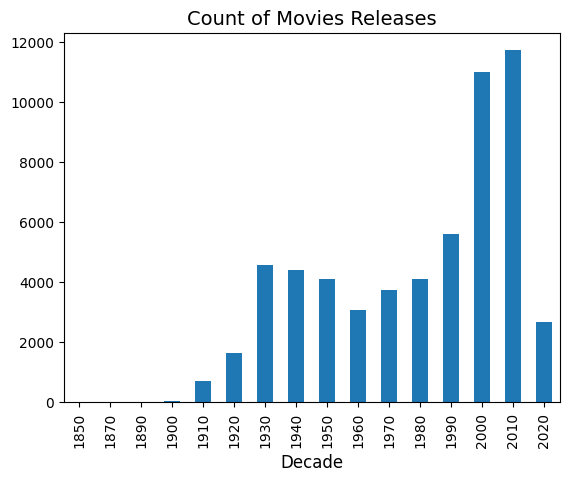

In [ ]:
# Filter the dataframe
plot_df = df[df['year'] < 2030]

# Create new plot
plt.figure(figsize=(10, 8))
plot_df.groupby(['decade']).count().plot(y='title',kind='bar',legend=False)

# Labels
plt.xlabel('Decade', fontsize = 12)
plt.title('Count of Movies Releases', fontsize = 14)
plt.show();

This chart shows the number of movies released each year:

<Figure size 1000x800 with 0 Axes>

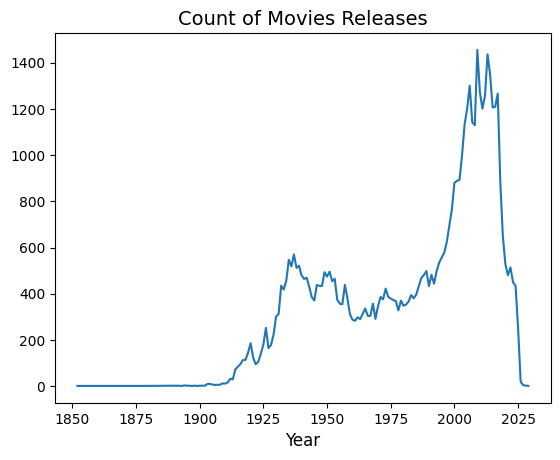

In [77]:
# Filter the dataframe
plot_df = df[df['year'] < 2030]

# Create new plot
plt.figure(figsize=(10, 8))
plot_df.groupby(['year']).count().plot(y='title',kind='line', legend=False)

# Labels
plt.xlabel('Year', fontsize = 12)
plt.title('Count of Movies Releases', fontsize = 14)
plt.show();

The full dataset includes some pioneering movies that were released pre-1900. Let's list those out:

In [80]:
df[df['year'] < 1900][['title','year', 'plot']].sort_values(by='year', ascending=True)

,title,year,plot
56104,Castle in the Air,1852,Unknown
49834,Passage de Venus,1874,The transit of Venus is captured in Japan by a...
48133,Sallie Gardner at a Gallop,1878,In what is widely considered to be the first f...
48131,"Monkeyshines, No. 1",1890,A man jokes around in what is thought to be Am...
49835,London's Trafalgar Square,1890,The hustle and bustle of Trafalgar Square is p...
48132,Dickson Greeting,1891,William Dickson passes his hat from one hand t...
49032,Newark Athlete,1891,An athlete is shown swinging Indian clubs.
49026,Blacksmith Scene,1893,"Three blacksmiths are hard at work, but occasi..."
49024,Carmencita,1894,The first female to ever to be captured in fil...
49023,Dickson Experimental Sound Film,1894,Two men waltz to a record being played.


Cinema goers often like to be among the first to see a new movie on the day it comes out. Therefore, it appears that movie releases are timed to take advantage of this fact; movies are released most often on a Friday.

<Figure size 1000x800 with 0 Axes>

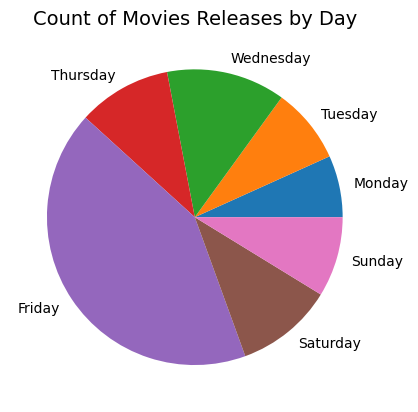

In [ ]:
# Filter the dataframe
plot_df = df[(df['year'] < 2026) & (df['year'] > 1900)]

# Create a custom order for the days of the week, or it will be alphabetical
custom_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plot_df['release_day'] = pd.Categorical(plot_df['release_day'], categories=custom_order, ordered=True)

# Create new plot
plt.figure(figsize=(10, 8))
df.groupby(['release_day']).count().plot(y='title',kind='pie', legend=False)

# Labels
plt.title('Count of Movies Releases by Day', fontsize = 14)
plt.ylabel('')
plt.show();

### Movie Languages

It is expected that the primary language for most movies will be English due to its prevalence globally.

<Figure size 1000x800 with 0 Axes>

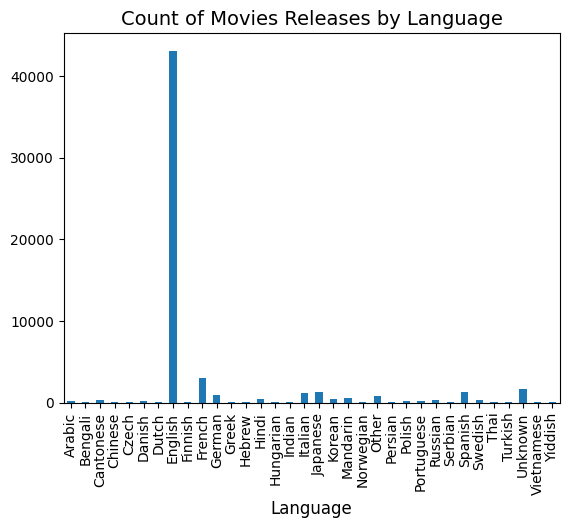

In [93]:
# Filter the dataframe
plot_df = df[(df['year'] < 2026) & (df['year'] > 1900)]

# Create new plot
plt.figure(figsize=(10, 8))
plot_df.groupby(['language']).count().plot(y='title',kind='bar', legend=False)

# Labels
plt.title('Count of Movies Releases by Language', fontsize = 14)
plt.ylabel('')
plt.xlabel('Language', fontsize = 12)
plt.show();

As expected, the most prevalent language for movies is English. But when this is removed, hopefully a more interesting picture will evolve:

<Figure size 1000x800 with 0 Axes>

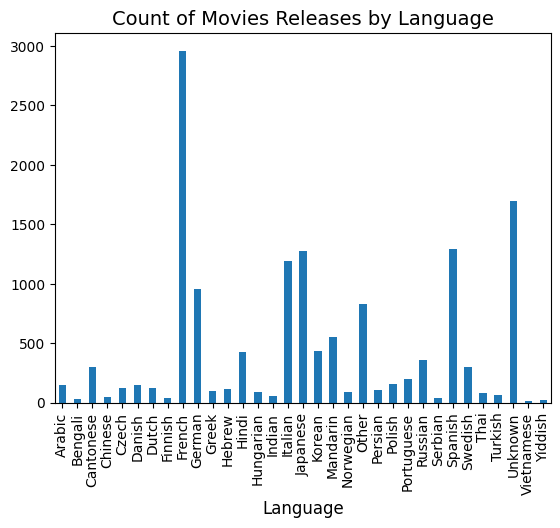

In [95]:
# Filter the dataframe
plot_df = df[(df['year'] < 2026) & (df['year'] > 1900) & (df['language'] != 'English')]

# Create new plot
plt.figure(figsize=(10, 8))
plot_df.groupby(['language']).count().plot(y='title',kind='bar', legend=False)

# Labels
plt.title('Count of Movies Releases by Language', fontsize = 14)
plt.ylabel('')
plt.xlabel('Language', fontsize = 12)
plt.show();

This chart shows the distribution of languages per decade:

<Figure size 1000x800 with 0 Axes>

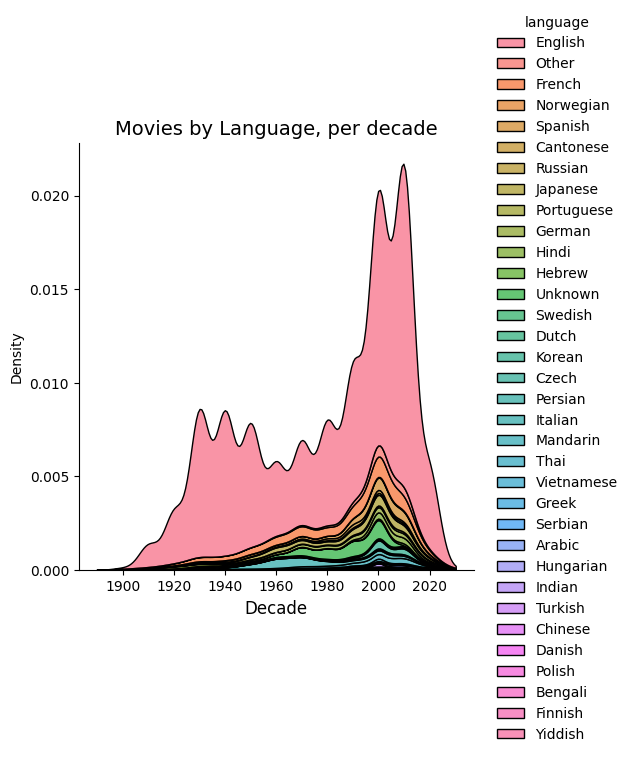

In [99]:
# Filter the dataframe
plot_df = df[(df['year'] < 2026) & (df['year'] > 1900)]
             
# Create new plot          ]
plt.figure(figsize=(10, 8))
ax = sns.displot(data=plot_df, x='decade', hue="language", multiple="stack", kind="kde", warn_singular=False);

# Labels
plt.title('Movies by Language, per decade', fontsize = 14)
plt.xlabel('Decade', fontsize = 12)
#plt.rcParams['axes.prop_cycle'] = cycler(color=cmap_terrain_as_list[::32])
plt.show();

And again, without English:

<Figure size 1000x800 with 0 Axes>

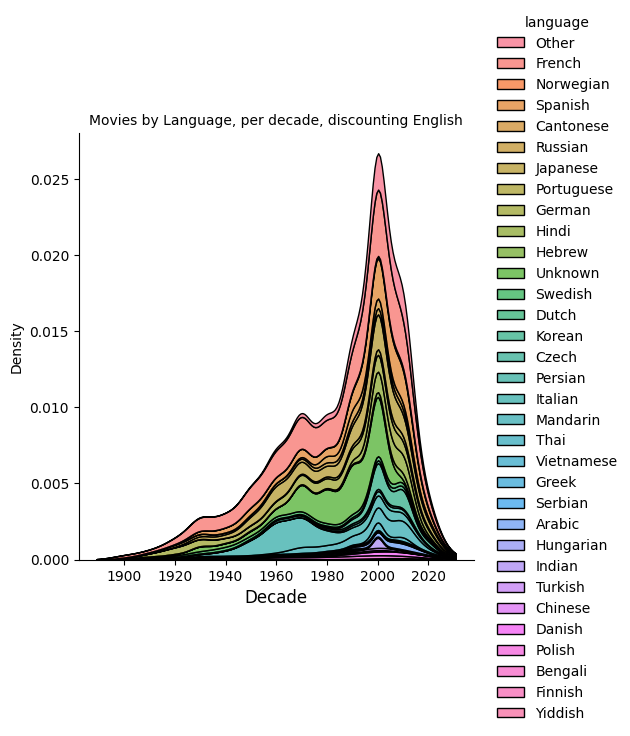

In [103]:
# Filter the dataframe
plot_df = df[(df['year'] < 2026) & (df['year'] > 1900) & (df['language'] != 'English')]
             
# Create new plot          ]
plt.figure(figsize=(10, 8))
ax = sns.displot(data=plot_df, x='decade', hue="language", multiple="stack", kind="kde", warn_singular=False);

# Labels
plt.title('Movies by Language, per decade, discounting English', fontsize = 10)
plt.xlabel('Decade', fontsize = 12)
#plt.rcParams['axes.prop_cycle'] = cycler(color=cmap_terrain_as_list[::32])
plt.show();

### MPAA Ratings

The Motion Picture Association of America (MPAA) is responsible for rating movies per their suitability for viewing by different age groups. The classification system began in 1968, and includes the following types:

**G – General Audiences**
All ages admitted. Nothing that would offend parents for viewing by children.

**PG – Parental Guidance Suggested**
All Ages Admitted

**PS/PG-13 – Parents Strongly Cautioned**
Some material may be inappropriate for children under 13. Parents are urged to be cautious. Some material may be inappropriate for pre-teenagers.

**R – Restricted**
Under 17 requires accompanying parent or adult guardian. Contains some adult material. Parents are urged to learn more about the film before taking their young children with them.

**NC-17 – Adults Only**
No one 17 and under admitted. Clearly adult. Children are not admitted.

The dataset also includes "NR" for Not Rated and "Unknown" where I could not determine the rating during the scraping process.

(Reference: https://www.filmratings.com/ and https://simple.wikipedia.org/wiki/Motion_Picture_Association_film_rating_system)

The following is a simple count of the ratings applied to the movies in the dataset:

<Figure size 1000x800 with 0 Axes>

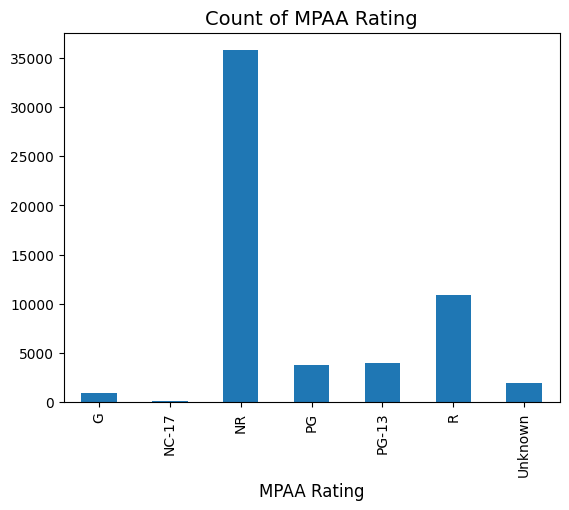

In [104]:
# Create new plot
plt.figure(figsize=(10, 8))
df.groupby(['mpaa_rating']).count().plot(y='title',kind='bar', legend=False)

# Labels
plt.xlabel('MPAA Rating', fontsize = 12)
plt.title('Count of MPAA Rating', fontsize = 14)
plt.show();

The following chart shows the MPAA rating count per decade.

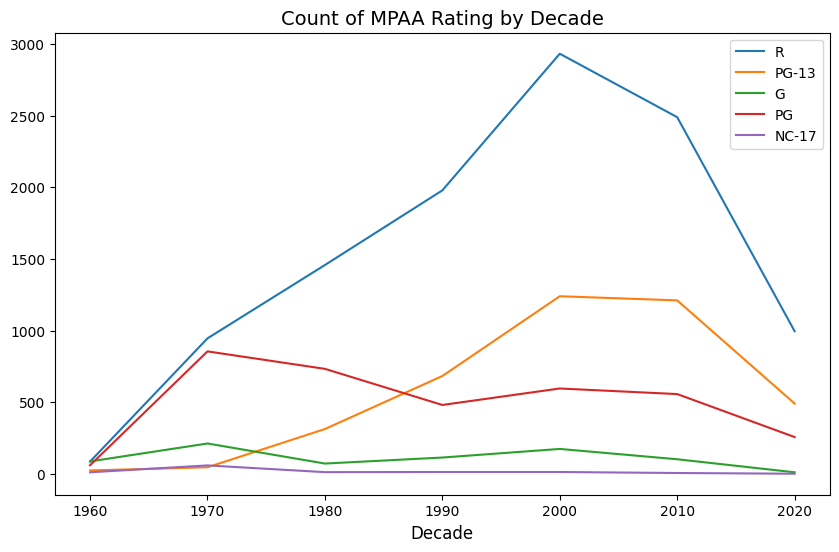

In [ ]:
# Filter the dataframe
plot_df = df[(df['mpaa_rating'] != 'NR') & (df['mpaa_rating'] != 'Unknown') & (df['year'] >= 1968 ) & (df['year'] < 2030)]

# Create new plot
plt.figure(figsize=(10, 6))

# Loop through the MPAA ratings and plot a line for each
for rating in plot_df['mpaa_rating'].unique():
    subset = plot_df[plot_df['mpaa_rating'] == rating]
    subset.groupby(['decade']).count().plot(y='mpaa_rating',kind='line', label=f'{rating}', ax=plt.gca())

# Labels
plt.xlabel('Decade', fontsize = 12)
plt.title('Count of MPAA Rating by Decade', fontsize = 14)
plt.show();

This chart shows the relative distribution of ratings across the years. Is it interesting to see that fewer movies have received a PG rating over time, while more have been made for an adult audience. From this chart and the one above, it seems to that more modern movies include adult themes and content than in the earlier days of the classification scheme. However, it may also be because of differing social acceptance of such themes.

<Figure size 1000x800 with 0 Axes>

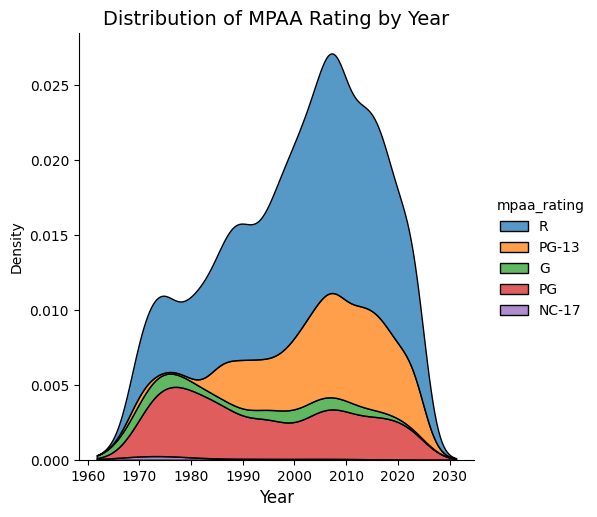

In [115]:
# Filter the dataframe
plot_df = df[(df['mpaa_rating'] != 'NR') & (df['mpaa_rating'] != 'Unknown') & (df['year'] >= 1968 ) & (df['year'] < 2030)]

# Create new plot
plt.figure(figsize=(10, 8))
ax = sns.displot(data=plot_df, x='year', hue="mpaa_rating", multiple="stack", kind="kde");

# Labels
plt.xlabel('Year', fontsize = 12)
plt.title('Distribution of MPAA Rating by Year', fontsize = 14)
plt.show();

### Genre

The most popular type of movie is a drama, followed by a comedy:

<Figure size 1000x800 with 0 Axes>

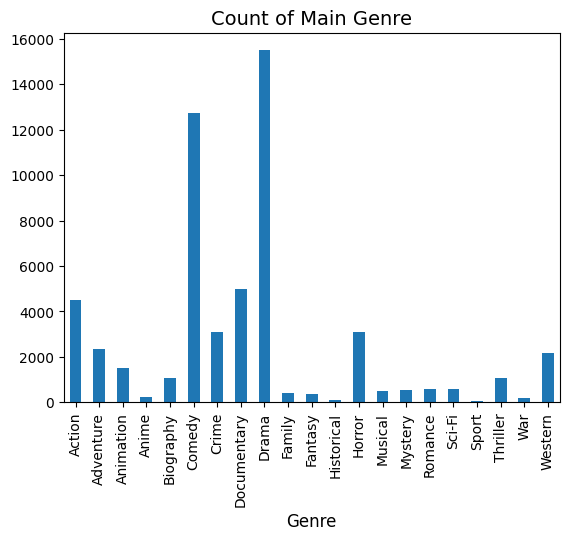

In [123]:
# Filter the dataframe
plot_df = df[(df['year'] < 2030) & (df['genre_main'] != 'Unknown')]

# Create new plot
plt.figure(figsize=(10, 8))
plot_df.groupby(['genre_main']).count().plot(y='title',kind='bar', legend=False)

# Labels
plt.xlabel('Genre', fontsize = 12)
plt.title('Count of Main Genre', fontsize = 14)
plt.show();

This graph shows the density of each genre over the decades:

<Figure size 1000x800 with 0 Axes>

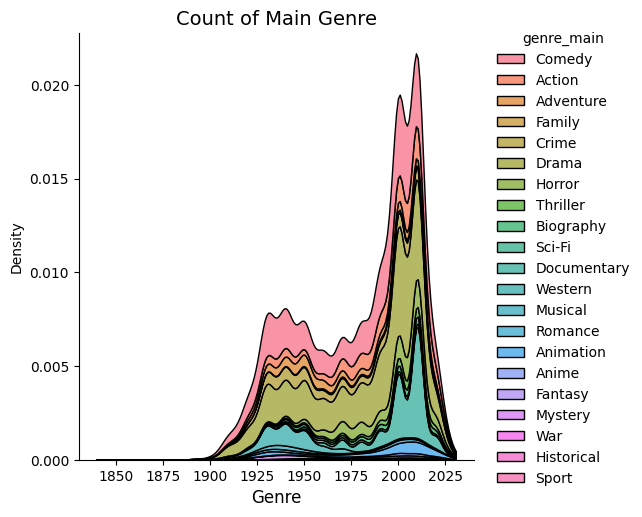

In [119]:
# Filter the dataframe
plot_df = df[(df['year'] < 2030) & (df['genre_main'] != 'Unknown')]

# Create new plot
plt.figure(figsize=(10, 8))
ax = sns.displot(data=plot_df, x='decade', hue="genre_main", multiple="stack", kind="kde", warn_singular=False);

# Labels
plt.xlabel('Genre', fontsize = 12)
plt.title('Count of Main Genre', fontsize = 14)
plt.show();

Here is a distribution plot for the average rating against the genre. Most movie genres follow the same approximate pattern.

<Figure size 1000x800 with 0 Axes>

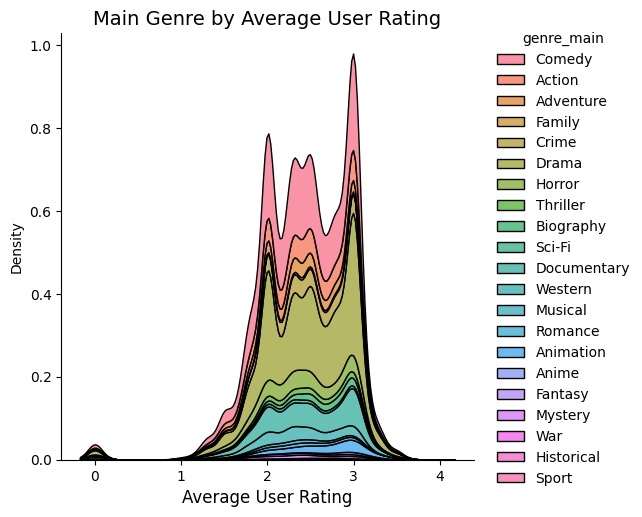

In [124]:
# Filter the dataframe
plot_df = df[(df['year'] < 2030) & (df['genre_main'] != 'Unknown')]

# Create new plot
plt.figure(figsize=(10, 8))
ax = sns.displot(data=plot_df, x='average_rating', hue="genre_main", multiple="stack", kind="kde", warn_singular=False);

# Labels
plt.xlabel('Average User Rating', fontsize = 12)
plt.title('Main Genre by Average User Rating', fontsize = 14)
plt.show();

### User Ratings

The users of the Filmcrave website are able to leave long form textual reviews (not scraped) and a rating from 0 to 5 for a movie. The dataset includes an average of these user rating and a value fo the number of ratings received.

This graph shows that the number of ratings received increases for more modern movies, peaking for the 2010's (although the 2020's are not yet half way through.) While we do not have the age of each user, this generally implies that people are rating movies that have been popular recently.

<Figure size 1000x800 with 0 Axes>

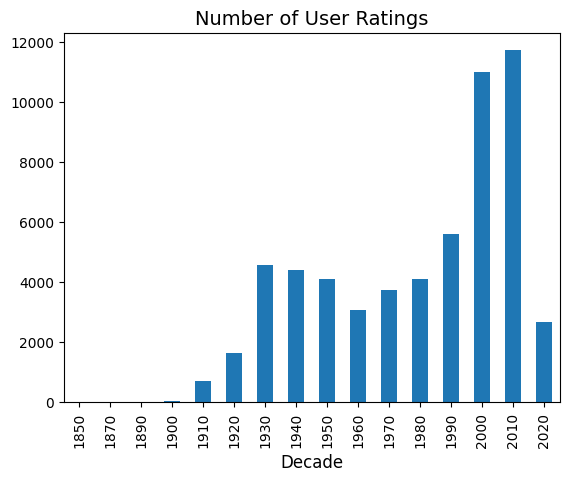

In [131]:
# Filter the dataframe
plot_df = df[df['year'] < 2030]

# Create new plot
plt.figure(figsize=(10, 8))
plot_df.groupby(['decade']).count().plot(y='number_ratings',kind='bar', legend=False)

# Labels
plt.xlabel('Decade', fontsize = 12)
plt.title('Number of User Ratings', fontsize = 14)
plt.show();

Exploring this in more detail, the following chart shows the number of ratings per year since 1990. The most popular movies for ratings were released in 2009 and 2013.

<Figure size 1000x800 with 0 Axes>

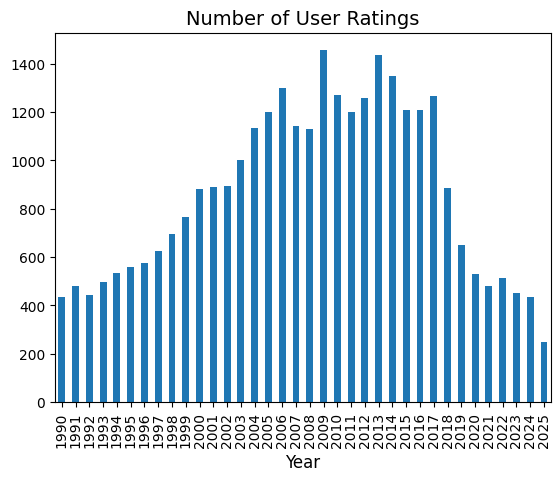

In [132]:
# Filter the dataframe
plot_df = df[(df['year'] < 2026) & (df['year'] >= 1990)]

# Create new plot
plt.figure(figsize=(10, 8))
plot_df.groupby(['year']).count().plot(y='number_ratings',kind='bar', legend=False)

# Labels
plt.xlabel('Year', fontsize = 12)
plt.title('Number of User Ratings', fontsize = 14)
plt.show();

Here is a list of the top 20 most rated films, along with their average rating and overall ranking:

In [32]:
df.nlargest(n=20, columns='number_ratings')[['title','number_ratings', 'average_rating', 'overall_rank']]

,title,number_ratings,average_rating,overall_rank
2865,Forrest Gump,2238,3.3,6
1887,The Dark Knight,2174,3.4,4
2695,Fight Club,2131,3.3,2
5128,The Matrix,2115,3.2,9
7154,The Shawshank Redemption,2081,3.5,1
6442,Pulp Fiction,2033,3.4,5
4797,Lord of the Rings: The Fellowship of the Ring,1963,3.3,7
4798,Lord of the Rings: The Return of the King,1852,3.4,8
565,Back to the Future,1768,3.2,19
7234,The Silence of the Lambs,1734,3.4,13


This graph shows the number of user ratings vs the average rating for the complete dataset, coloured by year (1990-2025).

<Figure size 1000x800 with 0 Axes>

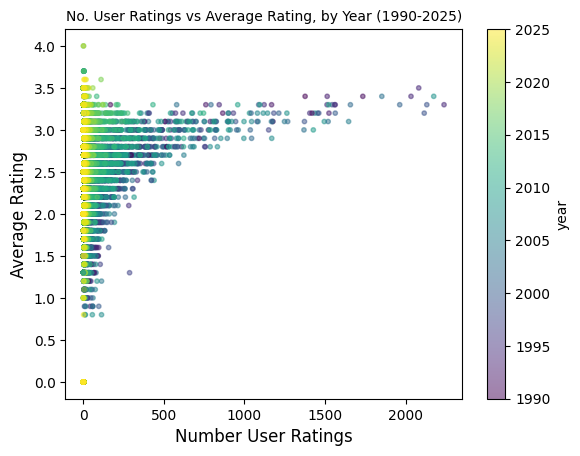

In [163]:
# Filter the dataframe
plot_df = df[(df['year'] < 2026) & (df['year'] >= 1990)][['number_ratings', 'average_rating', 'decade', 'year']]

# Create new plot
plt.figure(figsize=(10, 8))
plot_df.plot.scatter(x='number_ratings', y='average_rating', c='year', colormap='viridis', alpha=0.5, s=10)

# Labels
plt.xlabel('Number User Ratings', fontsize = 12)
plt.ylabel('Average Rating', fontsize = 12)
plt.title('No. User Ratings vs Average Rating, by Year (1990-2025)', fontsize = 10)
plt.show();


In comparison, Tthis graph shows the number of user ratings vs the average rating for the Top 1000 movies dataset, coloured by year (1990-2025). The average rating is filtered to be above 2.5 as there are a number of outliers with very low scores which make the graph unreadable.

<Figure size 1000x800 with 0 Axes>

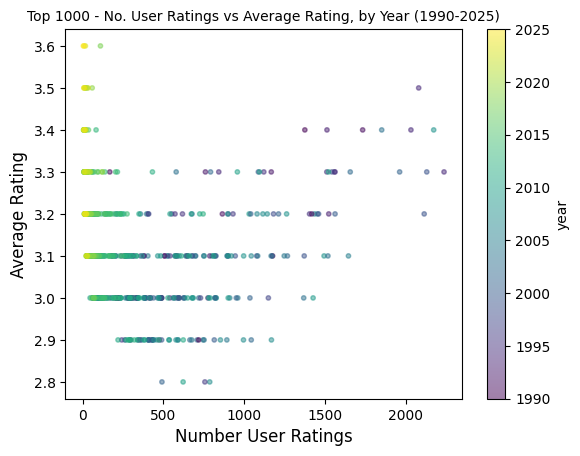

In [171]:
# Filter the dataframe
plot_df = df_top1000[(df_top1000['year'] < 2026) & (df['year'] >= 1990) & (df['average_rating'] > 2.5)][['number_ratings', 'average_rating', 'decade', 'year']]

# Create new plot
plt.figure(figsize=(10, 8))
plot_df.plot.scatter(x='number_ratings', y='average_rating', c='year', colormap='viridis', alpha=0.5, s=10)

# Labels
plt.xlabel('Number User Ratings', fontsize = 12)
plt.ylabel('Average Rating', fontsize = 12)
plt.title('Top 1000 - No. User Ratings vs Average Rating, by Year (1990-2025)', fontsize = 10)
plt.show();

### Titles and Plots

An interesting way to explore the textual data in the dataset is to create a word cloud. Here is one for movie titles:

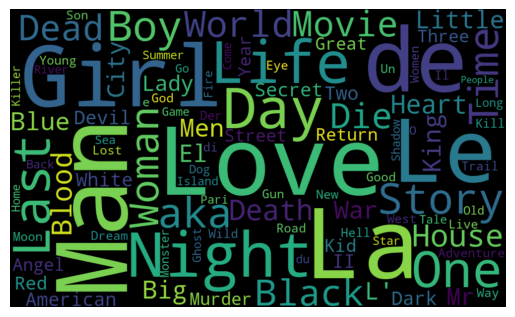

In [172]:
# Generate combined text
text = " ".join(txt for txt in df['title'])

# Create a word cloud image
wordcloud = WordCloud(max_font_size=200, max_words=100,width=1000,height=600).generate(text)

# Display
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

And for the text of the plot, where available:

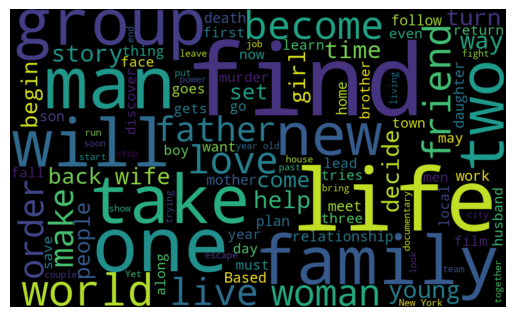

In [173]:
# Filter the dataframe and generate combined text
plot_df = df[df['plot'] != 'Unknown']
text = " ".join(txt for txt in plot_df['plot'])

# Create a word cloud image
wordcloud = WordCloud(max_font_size=200, max_words=100,width=1000,height=600).generate(text)

# Display
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

And finally for the main genre:

In [185]:
df['genre_main'].str.strip().unique()

array(['Comedy', 'Action', 'Adventure', 'Family', 'Crime', 'Drama',
       'Horror', 'Thriller', 'Biography', 'Sci-Fi', 'Documentary',
       'Western', 'Musical', 'Romance', 'Animation', 'Anime', 'Unknown',
       'Fantasy', 'Mystery', 'War', 'Historical', 'Sport'], dtype=object)

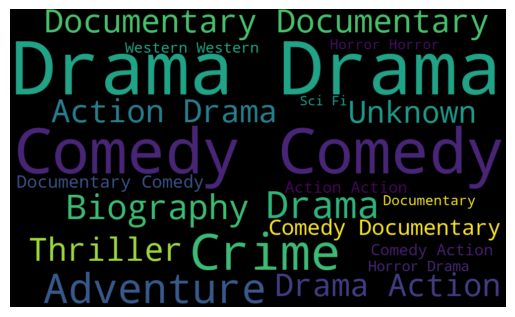

In [186]:
# Generate Combined Text
plot_df = df[df['genre_main'] != 'Unknown']
text = " ".join(txt for txt in df['genre_main'].str.strip())

# Create and generate a word cloud image:
wordcloud = WordCloud(max_font_size=200, max_words=20,width=1000,height=600).generate(text)

# Display the word cloud:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

## Actors and Directors

In [ ]:
# Deal with actors, and directors
# A set?